# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [2]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
# sns.set_theme()
sns.set_theme(style="white")
# sns.set_style('whitegrid')

from scipy.stats import wilcoxon, ranksums
from numpy import matlib
from scipy.stats.distributions import chi2
from sklearn.model_selection import KFold

In [3]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [4]:
# Load data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


In [20]:
# Load data
start_time = 0.15
end_time = 0.35
padding = 0.2
V1_peak2 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1_peak2.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1_peak2.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# Fit

In [96]:
# The following hyperparameters turned out to be the best
num_f_refractory = 4
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 15
penalty = 5e-1

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}

ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}

running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1_peak2.running_trial_index
    for j, input_probe in enumerate(probe_list):
        model = GLM.PP_GLM(dataset=V1_peak2, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('homogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
#         model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
#     model.add_effect('refractory', target_probe, tau=tau, order=1.5, apply_no_penalty=True)
        model.add_effect('trial_coef')
        model.fit(target_probe, verbose=False, penalty=penalty)
        
        filter_list = model.get_filter(ci=True)
        running_filter[i,j] = filter_list[1]
        output_list = model.get_filter_output(intermediate=False, ci=True)
        running_output[i,j] = output_list[1]
    running_model_list.append(model)
    
    select_trials = V1_peak2.stationary_trial_index
    for j, input_probe in enumerate(probe_list):
        model = GLM.PP_GLM(dataset=V1_peak2, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('homogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
#         model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
#     model.add_effect('refractory', target_probe, tau=tau, order=1.5, apply_no_penalty=True)
        model.add_effect('trial_coef')
        model.fit(target_probe, verbose=False, penalty=penalty)
        
        filter_list = model.get_filter(ci=True)
        stationary_filter[i,j] = filter_list[1]
        output_list = model.get_filter_output(intermediate=False, ci=True)
        stationary_output[i,j] = output_list[1]
    stationary_model_list.append(model)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
baseline_aic = 570714.232742189
print(f"AIC improvement of the model is: {(baseline_aic - aic)}")

bic = np.sum([model.bic for model in stationary_model_list]+[model.bic for model in running_model_list])
baseline_bic = 588924.4932276756
print(f"BIC improvement of the model is: {(baseline_bic - bic)}")

6it [00:31,  5.22s/it]

AIC improvement of the model is: 326764.9825405291
BIC improvement of the model is: 334536.1490482494


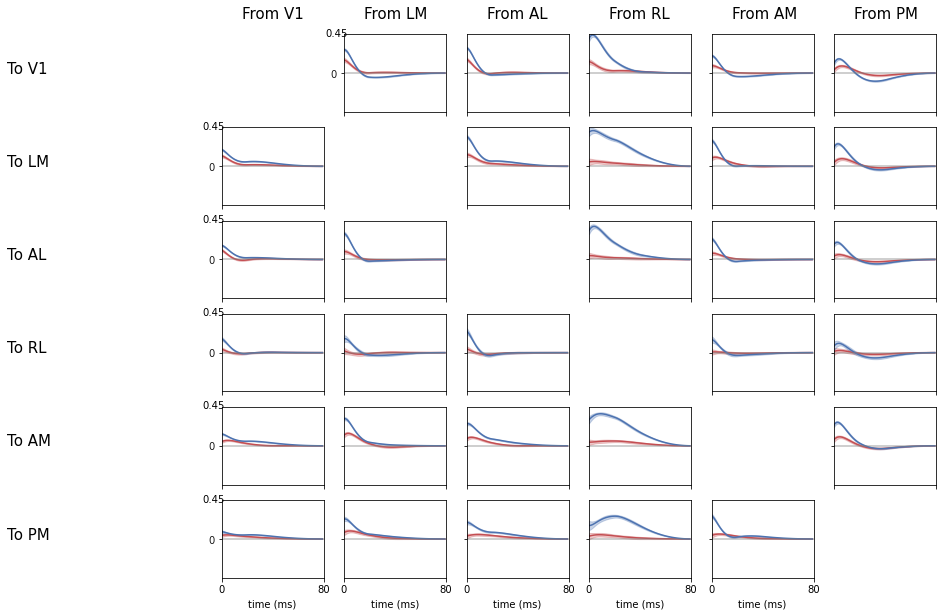

In [100]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, inference=False, plot_baseline=False, 
                              plot_self=False, output=False, filter_amp=0.45)

# V1 to LM

In [55]:
target_probe = 'probeD'
input_probe = 'probeC'

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('homogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
model.add_effect('coupling', input_probe, apply_no_penalty=True, **coupling_filter_params)
#         model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
#     model.add_effect('refractory', target_probe, tau=tau, order=1.5, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit(target_probe, verbose=False, penalty=penalty)
running_model = model


select_trials = V1.stationary_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('homogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
model.add_effect('coupling', input_probe, apply_no_penalty=True, **coupling_filter_params)
#         model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
#     model.add_effect('refractory', target_probe, tau=tau, order=1.5, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit(target_probe, verbose=False, penalty=penalty)
stationary_model = model

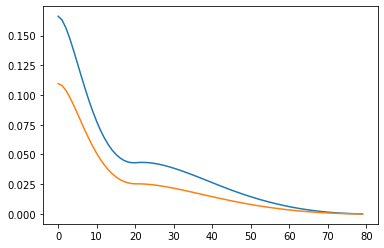

In [56]:
plt.plot(stationary_model.get_filter(ci=True)[1][0])
plt.plot(running_model.get_filter(ci=True)[1][0])

In [58]:
target_probe = 'probeD'
input_probe = 'probeC'

select_trials = V1_peak2.running_trial_index
model = GLM.PP_GLM(dataset=V1_peak2, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('homogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
model.add_effect('coupling', input_probe, apply_no_penalty=True, **coupling_filter_params)
#         model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
#     model.add_effect('refractory', target_probe, tau=tau, order=1.5, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit(target_probe, verbose=False, penalty=penalty)
running_model = model

select_trials = V1_peak2.stationary_trial_index
model = GLM.PP_GLM(dataset=V1_peak2, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('homogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
model.add_effect('coupling', input_probe, apply_no_penalty=True, **coupling_filter_params)
#         model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
#     model.add_effect('refractory', target_probe, tau=tau, order=1.5, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit(target_probe, verbose=False, penalty=penalty)
stationary_model = model

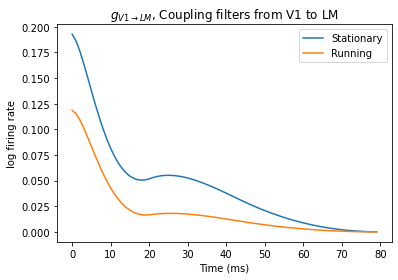

In [84]:
plt.plot(stationary_model.get_filter(ci=True)[1][0], label="Stationary")
plt.plot(running_model.get_filter(ci=True)[1][0], label="Running")
plt.title(r"$g_{V1 \rightarrow LM}$, Coupling filters from V1 to LM")
plt.xlabel("Time (ms)")
plt.ylabel("log firing rate")
plt.legend()

In [25]:
target_probe = 'probeC'
num_basis_baseline = 20

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
# model.add_effect('coupling', input_probe, apply_no_penalty=True, **coupling_filter_params)
#         model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
#     model.add_effect('refractory', target_probe, tau=tau, order=1.5, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
running_modelV1 = model

select_trials = V1.stationary_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
# model.add_effect('coupling', input_probe, apply_no_penalty=True, **coupling_filter_params)
#         model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
#     model.add_effect('refractory', target_probe, tau=tau, order=1.5, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
stationary_modelV1 = model

(-5.0, 100.0)

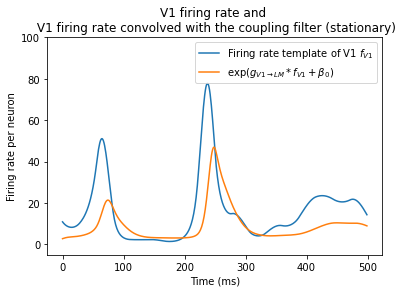

In [95]:
V1fr = np.exp(stationary_modelV1.get_filter()[0])
plt.plot(V1fr/17*1e3, label=r"Firing rate template of V1 $f_{V1}$")
plt.plot(np.exp(GLM.conv(V1fr,stationary_model.get_filter(ci=True)[1][0])-3.52)/10.6*1e3,
         label=r"$\exp(g_{V1 \rightarrow LM}*f_{V1}+\beta_0)$")
plt.xlabel("Time (ms)")
plt.ylabel("Firing rate per neuron")
plt.legend()
plt.title("V1 firing rate and \n V1 firing rate convolved with the coupling filter (stationary)")
plt.ylim([-5, 100])
# plt.xlim([150, 350])
